<a href="https://colab.research.google.com/github/aniilkeles/Machine-Learning-Projects/blob/main/Unsupervised%20Learning/52_HierarchicalClusteringipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/27-mall_customers.csv')

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

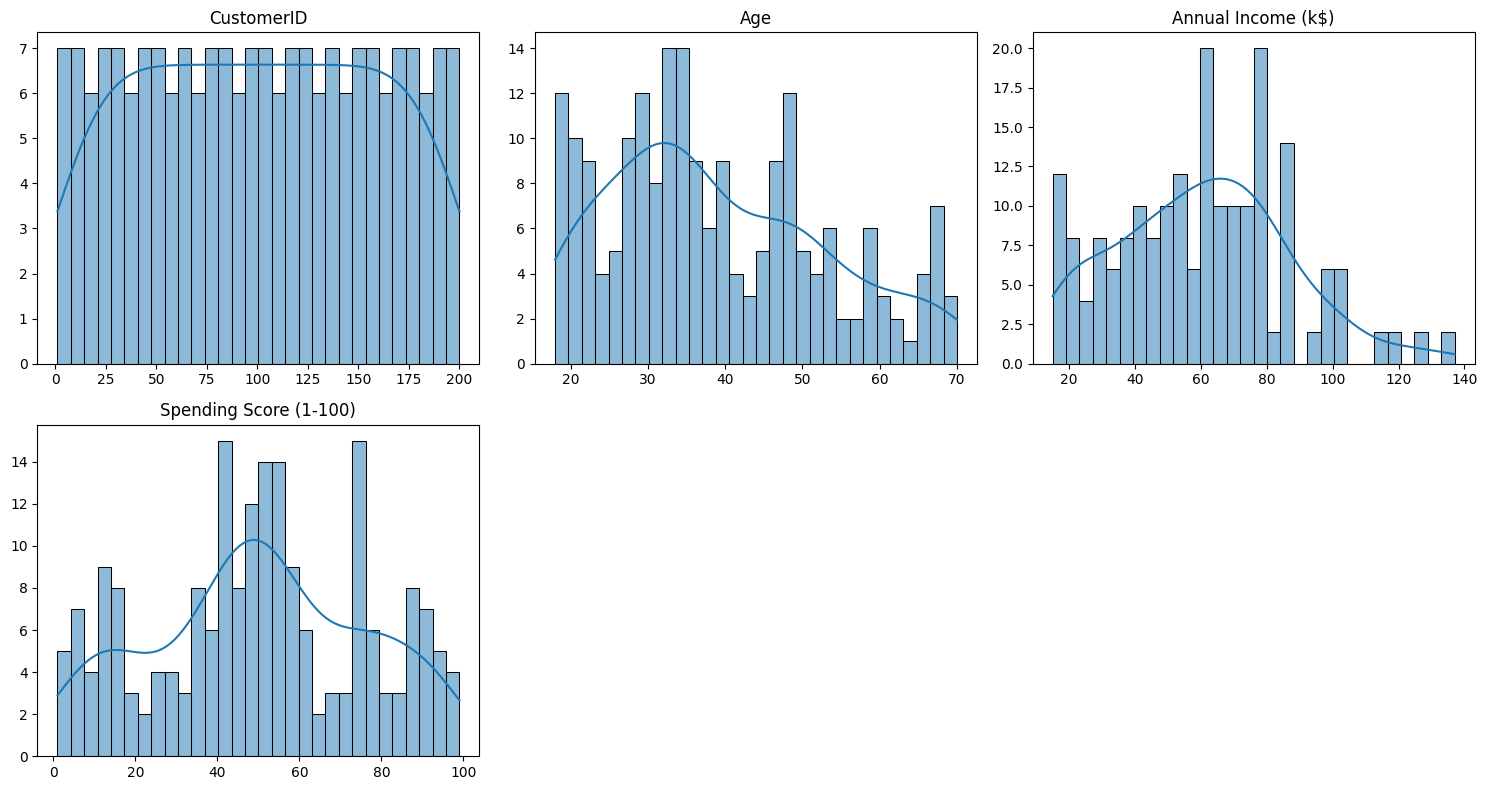

In [8]:
plot_all_histograms(df)

In [9]:
df['Gender'].value_counts()

,count
Gender,
Female,112
Male,88


In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(df['Gender'])

In [12]:
df['Gender'].value_counts()

,count
Gender,
0,112
1,88


In [13]:
df = df.drop('CustomerID',axis=1)

In [14]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [18]:
df = pd.DataFrame(df_scaled , columns = df.columns)

In [19]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959


In [20]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

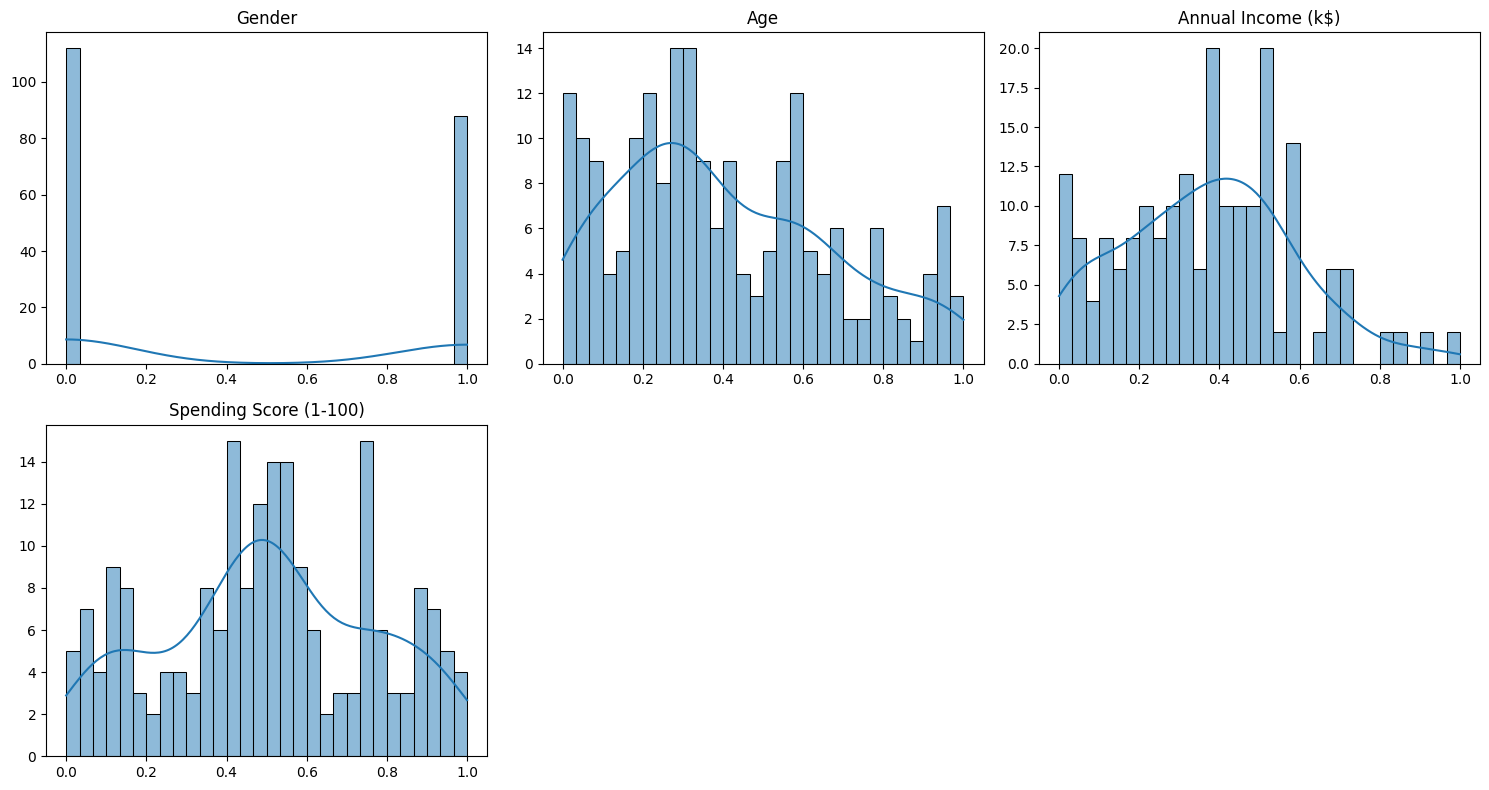

In [21]:
plot_all_histograms(df)

In [22]:
import scipy.cluster.hierarchy as sch

In [23]:
# https://scikit-learn.org/stable/auto_examples/cluster/plot_linkage_comparison.html#sphx-glr-auto-examples-cluster-plot-linkage-comparison-py
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage

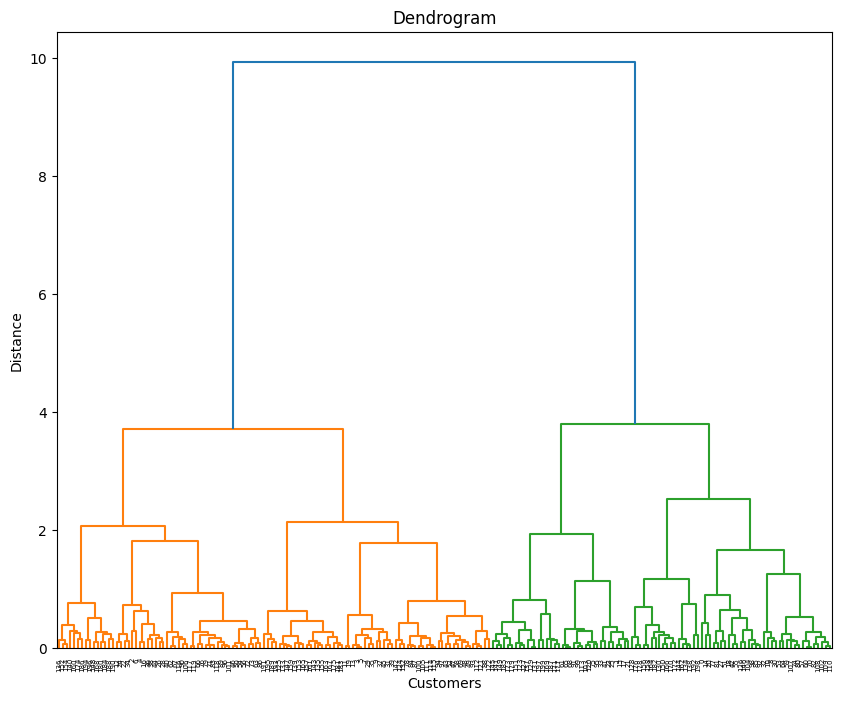

In [25]:
plt.figure(1, figsize = (10,8))
dendrogram = sch.dendrogram(sch.linkage(df, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [26]:
# we can clearly select 4 to 6 clusters from this dendrogram, let's go for 4

In [27]:
from sklearn.cluster import AgglomerativeClustering

In [29]:
hc = AgglomerativeClustering(n_clusters=4)

In [33]:
y_hc = hc.fit_predict(df)

In [34]:
y_hc

array([0, 2, 3, 1, 3, 1, 3, 1, 0, 1, 0, 1, 3, 1, 0, 2, 3, 2, 0, 1, 0, 2,
       3, 2, 3, 2, 3, 0, 3, 1, 0, 1, 0, 2, 3, 1, 3, 1, 3, 1, 3, 2, 0, 1,
       3, 1, 3, 1, 1, 1, 3, 0, 1, 0, 3, 0, 3, 0, 1, 0, 0, 2, 3, 3, 0, 2,
       3, 3, 2, 1, 0, 3, 3, 3, 0, 2, 3, 0, 1, 3, 0, 0, 0, 3, 1, 0, 3, 1,
       1, 3, 3, 2, 0, 1, 1, 2, 3, 1, 0, 2, 1, 3, 0, 2, 0, 1, 3, 0, 0, 0,
       0, 1, 1, 2, 1, 1, 3, 3, 3, 3, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2, 0, 2,
       1, 1, 0, 1, 3, 2, 0, 1, 3, 2, 1, 1, 0, 2, 0, 1, 3, 2, 0, 2, 3, 1,
       3, 1, 0, 1, 0, 1, 3, 1, 0, 1, 0, 1, 0, 1, 3, 2, 0, 2, 0, 2, 3, 1,
       0, 2, 0, 2, 3, 1, 0, 1, 3, 2, 3, 2, 3, 1, 3, 1, 0, 1, 3, 1, 3, 2,
       0, 2])

In [35]:
df['cluster'] = pd.DataFrame(y_hc)

In [36]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1.0,0.019231,0.000000,0.387755,0
1,1.0,0.057692,0.000000,0.816327,2
2,0.0,0.038462,0.008197,0.051020,3
3,0.0,0.096154,0.008197,0.775510,1
4,0.0,0.250000,0.016393,0.397959,3


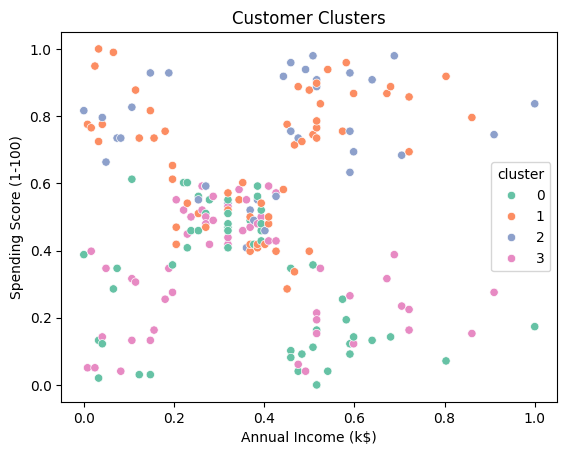

In [39]:
sns.scatterplot(data=df,x="Annual Income (k$)",y="Spending Score (1-100)",hue="cluster",palette = "Set2")
plt.title("Customer Clusters")
plt.show()

In [40]:
from sklearn.metrics import silhouette_score

In [41]:
print(silhouette_score(df,y_hc))

0.7143503785893516


In [42]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]].copy()

In [43]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,0.000000,0.387755
1,0.000000,0.816327
2,0.008197,0.051020
3,0.008197,0.775510
4,0.016393,0.397959


In [48]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X)
X['cluster'] = y_hc

In [49]:
X

,Annual Income (k$),Spending Score (1-100),cluster
0,0.000000,0.387755,4
1,0.000000,0.816327,3
2,0.008197,0.051020,4
3,0.008197,0.775510,3
4,0.016393,0.397959,4
...,...,...,...
195,0.860656,0.795918,0
196,0.909836,0.275510,1
197,0.909836,0.744898,0
198,1.000000,0.173469,1


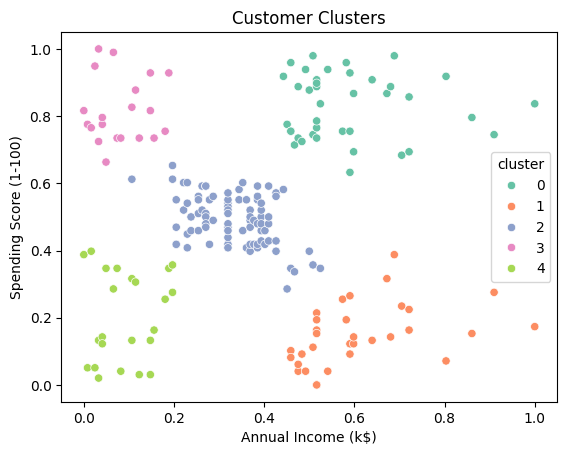

In [50]:
sns.scatterplot(data=X,x="Annual Income (k$)",y="Spending Score (1-100)",hue="cluster",palette = "Set2")
plt.title("Customer Clusters")
plt.show()

In [51]:
# kolon sayısını azalttık daha iyi sonuç aldık diyebiliriz ama yukarıdaki grafikte 4 boyut var ama biz 2 boyuttan baktık sadece bu yüzden 4 boyuttan baksaydık belki daha iyi gözlemleyebilirdik.

In [53]:
print(silhouette_score(X, y_hc))

0.8524094908064438


In [54]:
# silhouette_score kontrol edince modelin başarısını arttığını görüyoruz bu yüzden sadece 4 boyut ya da 2 boyut mesele değil.
# 2 boyuta indirgeyince modelin başarısını arttığını gözlemlemiş olduk.

In [55]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

In [57]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/27-mall_customers.csv')
df = df.drop("CustomerID",axis=1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

features_2d = ["Annual Income (k$)","Spending Score (1-100)"]
features_3d = ["Age","Annual Income (k$)","Spending Score (1-100)"]
features_4d = ["Gender","Age","Annual Income (k$)","Spending Score (1-100)"]

for feats in [features_2d,features_3d,features_4d]:
  X = df[feats]
  X_scaled = MinMaxScaler().fit_transform(X)

  hc = AgglomerativeClustering(n_clusters=5)
  y_hc = hc.fit_predict(X_scaled)

  sil = silhouette_score(X_scaled,y_hc)
  db = davies_bouldin_score(X_scaled,y_hc)
  ch = calinski_harabasz_score(X_scaled,y_hc)

  print(f"\n features :{feats}")
  print("Silhoutte score: ", sil)
  print("Davies Bouldin score: ", db)
  print("Calinski Harabasz score: ", ch)
  print("-------------")


 features :['Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.5582698727196419
Davies Bouldin score:  0.5734519252471811
Calinski Harabasz score:  258.97400737720704
-------------

 features :['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.3955454334726547
Davies Bouldin score:  0.8746143334035464
Calinski Harabasz score:  123.99070840826577
-------------

 features :['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.35032447507156306
Davies Bouldin score:  1.0941951795238571
Calinski Harabasz score:  163.46602356383625
-------------


In [58]:
# Davies Bouldin nin düşmesi calinskinin artması bizim için olumlu bir şey

In [59]:
from sklearn.cluster import KMeans

In [61]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/27-mall_customers.csv')
df = df.drop("CustomerID", axis = 1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

features_2d = ["Annual Income (k$)","Spending Score (1-100)"]
features_3d = ["Age","Annual Income (k$)","Spending Score (1-100)"]
features_4d = ["Gender","Age","Annual Income (k$)","Spending Score (1-100)"]

for feats in [features_2d,features_3d,features_4d]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    kmeans = KMeans(n_clusters=5)
    y_hc = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, y_hc)
    db = davies_bouldin_score(X_scaled, y_hc)
    ch = calinski_harabasz_score(X_scaled, y_hc)


    print(f"\n features :{feats}")
    print("Silhoutte score: ", sil)
    print("Davies Bouldin score: ", db)
    print("Calinski Harabasz score: ", ch)
    print("-------------")


 features :['Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.5593469429051445
Davies Bouldin score:  0.5616471225010365
Calinski Harabasz score:  264.5506476775083
-------------

 features :['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.40729930362661093
Davies Bouldin score:  0.8809862268641455
Calinski Harabasz score:  127.87168185221311
-------------

 features :['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte score:  0.3683074597529098
Davies Bouldin score:  1.0441145500406117
Calinski Harabasz score:  164.4198215512412
-------------


In [62]:
# Silhoutte score hesaplarken içine cluster kolon olmadan hesaplanır.